# กิจกรรมที่ 2 & 4: การทดลองภาคสนาม (Motion Scenarios) และการแสดงผล/วิเคราะห์ข้อมูล

**เซนเซอร์ที่ใช้:**
1. IMU Sensor — Acceleration (acc_x, acc_y, acc_z) & Gyroscope (gyro_x, gyro_y, gyro_z)
2. Distance Sensor (ToF) — distance (mm)

---

In [16]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import os

# ตั้งค่าสไตล์และขนาดกราฟเดี่ยวให้ใหญ่ชัดเจน
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Base path 
BASE = os.path.dirname(os.path.abspath('__file__'))

def read_csv_file(filepath):
    """อ่านไฟล์ CSV แล้วคืนค่าเป็น dict ของ numpy arrays"""
    with open(filepath, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        header = next(reader)
        rows = []
        for row in reader:
            if not row or row[0].strip() == '':
                continue
            try:
                rows.append([float(x) for x in row])
            except ValueError:
                continue
    arr = np.array(rows)
    result = {}
    for i, col_name in enumerate(header):
        result[col_name.strip()] = arr[:, i]
    return result, header

def load_scenario(scenario_num):
    """โหลดไฟล์ CSV ทั้ง 3 ของแต่ละ scenario"""
    folder = os.path.join(BASE, f'scenerio_{scenario_num}')
    
    acc, _ = read_csv_file(os.path.join(folder, 'ACC.csv'))
    gyro, _ = read_csv_file(os.path.join(folder, 'GYRO.csv'))
    dist_raw, dist_header = read_csv_file(os.path.join(folder, 'Distance.csv'))
    
    # แปลงชื่อคอลัมน์ Distance 
    dist = {'Time': dist_raw['Time']}
    for key in dist_raw:
        if key != 'Time':
            dist['Distance'] = dist_raw[key]
            break
    
    return acc, gyro, dist

# โหลดข้อมูลทุก scenario
data = {}
for i in range(1, 7):
    data[i] = load_scenario(i)
    acc, gyro, dist = data[i]
    print(f'Scenario {i}: ACC={len(acc["Time"])} rows, GYRO={len(gyro["Time"])} rows, Distance={len(dist["Time"])} rows')

print('\nโหลดข้อมูลครบทุก scenario เรียบร้อย!')

Scenario 1: ACC=431 rows, GYRO=431 rows, Distance=415 rows
Scenario 2: ACC=504 rows, GYRO=504 rows, Distance=515 rows
Scenario 3: ACC=367 rows, GYRO=367 rows, Distance=371 rows
Scenario 4: ACC=331 rows, GYRO=331 rows, Distance=332 rows
Scenario 5: ACC=308 rows, GYRO=308 rows, Distance=304 rows
Scenario 6: ACC=268 rows, GYRO=268 rows, Distance=266 rows

โหลดข้อมูลครบทุก scenario เรียบร้อย!


---
## สถานการณ์ที่ 1: หุ่นยนต์หยุดนิ่ง (Stationary)

**การทดลอง:** วางหุ่นยนต์บนพื้นเรียบ ไม่ให้เคลื่อนที่ บันทึกข้อมูล 30 วินาที  
**วิเคราะห์:** Noise ของเซนเซอร์ และค่าพื้นฐาน (Baseline)

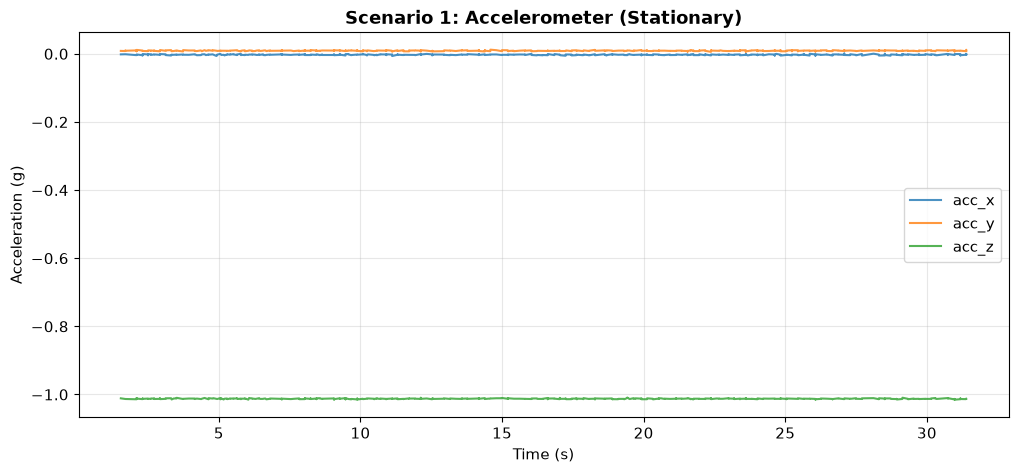

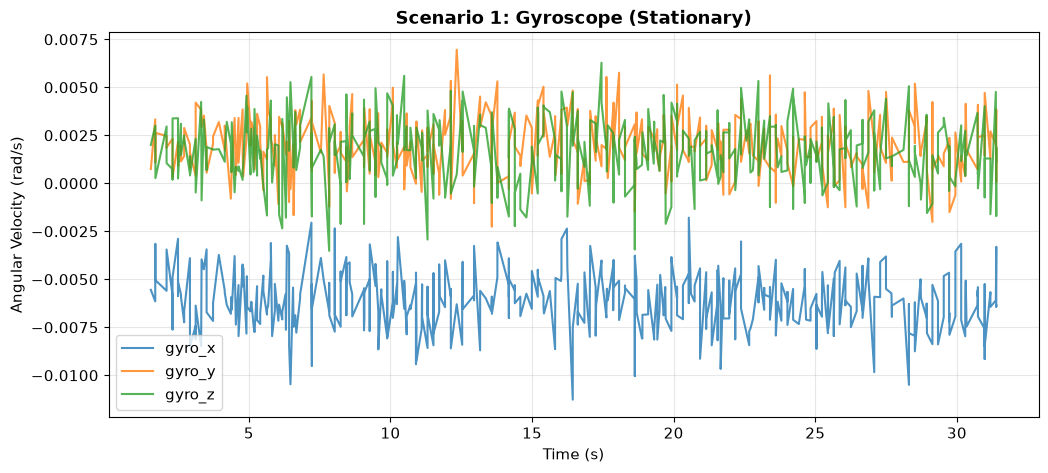

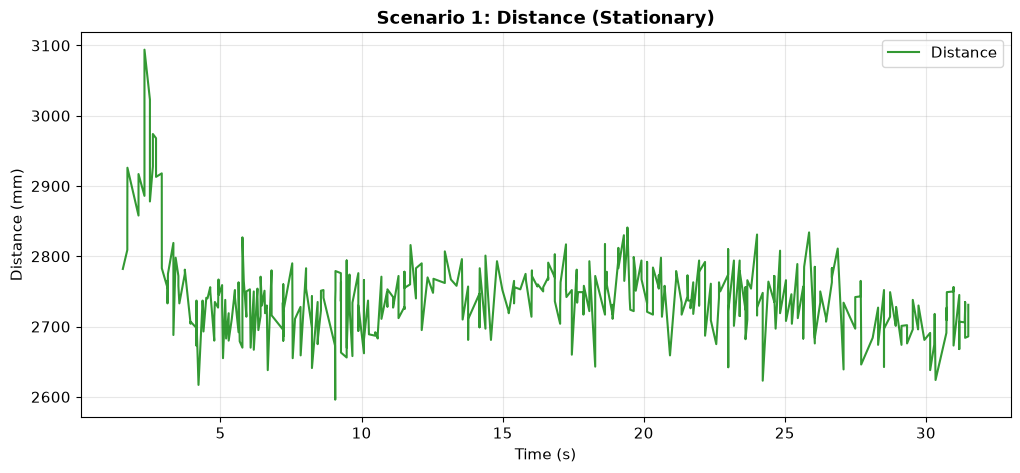

=== Noise Analysis (Stationary Baseline) ===

Acceleration (g):
  acc_x: mean=-0.00262, std=0.00121, range=[-0.00652, 0.00069]
  acc_y: mean=0.00913, std=0.00098, range=[0.00580, 0.01218]
  acc_z: mean=-1.01248, std=0.00104, range=[-1.01522, -1.00904]

Gyroscope (rad/s):
  gyro_x: mean=-0.00611, std=0.00149, range=[-0.01127, -0.00179]
  gyro_y: mean=0.00201, std=0.00148, range=[-0.00226, 0.00696]
  gyro_z: mean=0.00164, std=0.00167, range=[-0.00352, 0.00628]

Distance (mm):
  Distance: mean=2742.8, std=57.2, range=[2596, 3094]


In [17]:
acc1, gyro1, dist1 = data[1]

# Acceleration 
plt.figure(figsize=(12, 5))
plt.plot(acc1['Time'], acc1['acc_x'], label='acc_x', alpha=0.8)
plt.plot(acc1['Time'], acc1['acc_y'], label='acc_y', alpha=0.8)
plt.plot(acc1['Time'], acc1['acc_z'], label='acc_z', alpha=0.8)
plt.title('Scenario 1: Accelerometer (Stationary)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

#  Gyroscope 
plt.figure(figsize=(12, 5))
plt.plot(gyro1['Time'], gyro1['gyro_x'], label='gyro_x', alpha=0.8)
plt.plot(gyro1['Time'], gyro1['gyro_y'], label='gyro_y', alpha=0.8)
plt.plot(gyro1['Time'], gyro1['gyro_z'], label='gyro_z', alpha=0.8)
plt.title('Scenario 1: Gyroscope (Stationary)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.show()

# Distance 
plt.figure(figsize=(12, 5))
plt.plot(dist1['Time'], dist1['Distance'], label='Distance', color='green', alpha=0.8)
plt.title('Scenario 1: Distance (Stationary)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Distance (mm)')
plt.legend()
plt.show()

# สถิติ Noise 
print('=== Noise Analysis (Stationary Baseline) ===')
print('\nAcceleration (g):')
for col in ['acc_x', 'acc_y', 'acc_z']:
    print(f'  {col}: mean={np.mean(acc1[col]):.5f}, std={np.std(acc1[col]):.5f}, range=[{np.min(acc1[col]):.5f}, {np.max(acc1[col]):.5f}]')

print('\nGyroscope (rad/s):')
for col in ['gyro_x', 'gyro_y', 'gyro_z']:
    print(f'  {col}: mean={np.mean(gyro1[col]):.5f}, std={np.std(gyro1[col]):.5f}, range=[{np.min(gyro1[col]):.5f}, {np.max(gyro1[col]):.5f}]')

print('\nDistance (mm):')
print(f'  Distance: mean={np.mean(dist1["Distance"]):.1f}, std={np.std(dist1["Distance"]):.1f}, range=[{np.min(dist1["Distance"]):.0f}, {np.max(dist1["Distance"]):.0f}]')

---
## สถานการณ์ที่ 2: เคลื่อนที่ตรงด้วยความเร็วคงที่

**การทดลอง:** ให้หุ่นยนต์วิ่งตรงระยะประมาณ 3 เมตร ด้วยความเร็วคงที่  
**วิเคราะห์:** acc_x, gyro_z, Distance

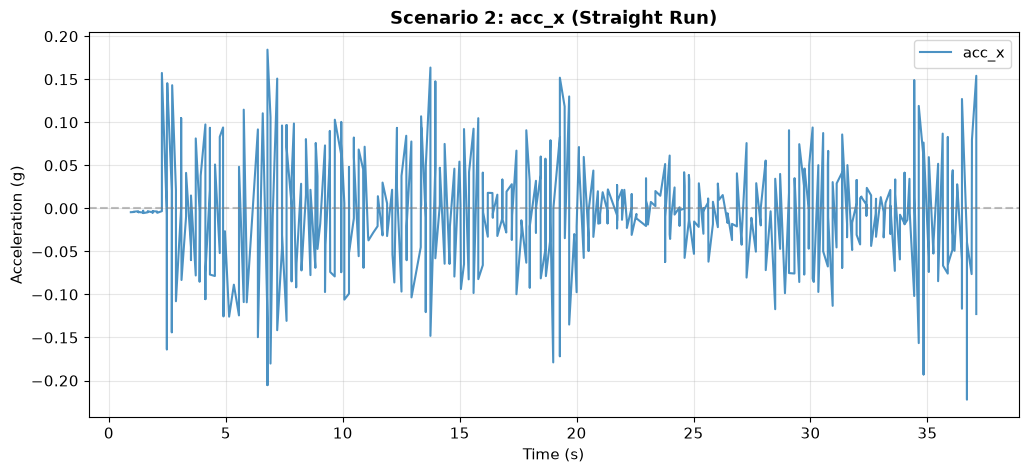

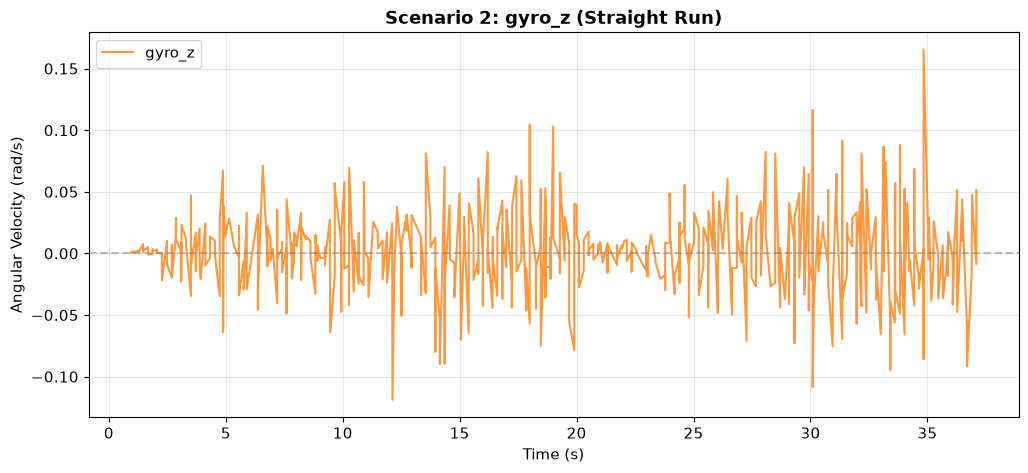

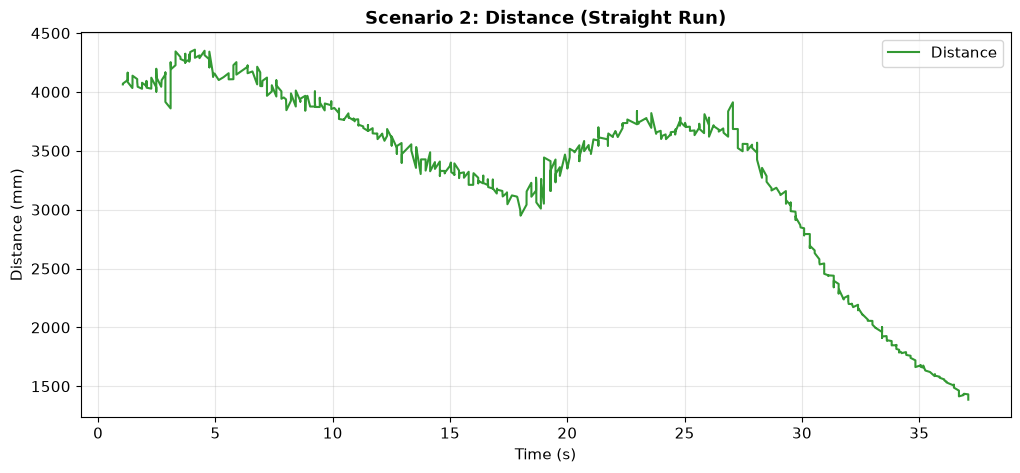

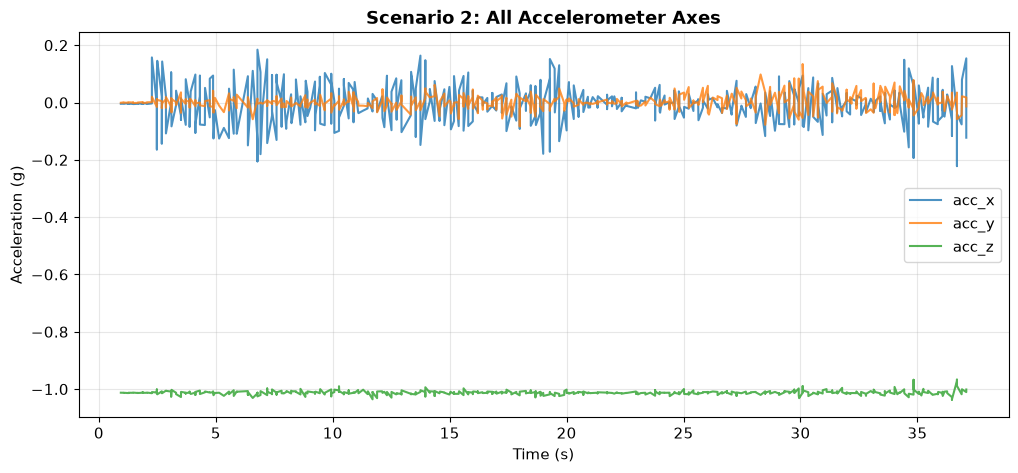

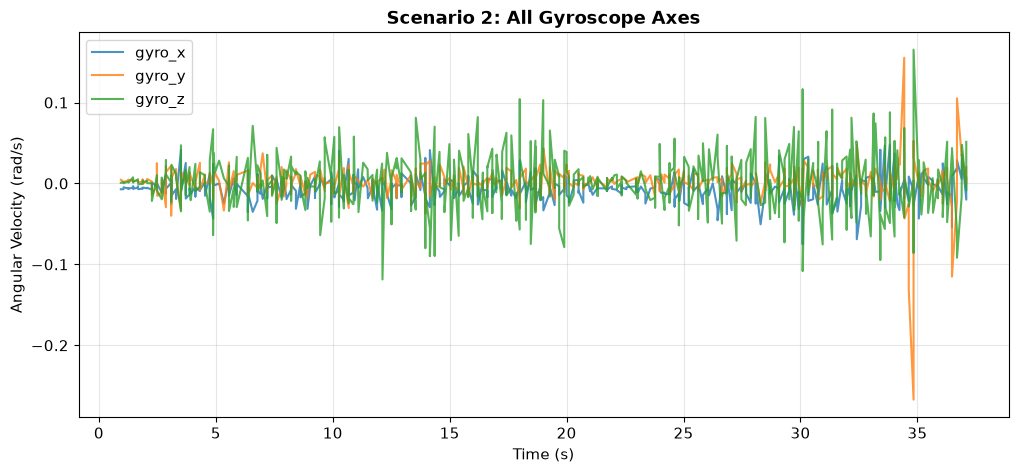

=== สถิติ Scenario 2: Straight Run ===
acc_x: mean=-0.00589, std=0.06391, max_abs=0.22222
gyro_z: mean=0.00127, std=0.03456, max_abs=0.16530
Distance: min=1386, max=4359, range=2973


In [18]:
acc2, gyro2, dist2 = data[2]

# acc_x 
plt.figure(figsize=(12, 5))
plt.plot(acc2['Time'], acc2['acc_x'], label='acc_x', color='tab:blue', alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Scenario 2: acc_x (Straight Run)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

# gyro_z 
plt.figure(figsize=(12, 5))
plt.plot(gyro2['Time'], gyro2['gyro_z'], label='gyro_z', color='tab:orange', alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Scenario 2: gyro_z (Straight Run)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.show()

# Distance 
plt.figure(figsize=(12, 5))
plt.plot(dist2['Time'], dist2['Distance'], label='Distance', color='green', alpha=0.8)
plt.title('Scenario 2: Distance (Straight Run)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Distance (mm)')
plt.legend()
plt.show()

# All Accelerometer Axes 
plt.figure(figsize=(12, 5))
plt.plot(acc2['Time'], acc2['acc_x'], label='acc_x', alpha=0.8)
plt.plot(acc2['Time'], acc2['acc_y'], label='acc_y', alpha=0.8)
plt.plot(acc2['Time'], acc2['acc_z'], label='acc_z', alpha=0.8)
plt.title('Scenario 2: All Accelerometer Axes', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

# All Gyroscope Axes 
plt.figure(figsize=(12, 5))
plt.plot(gyro2['Time'], gyro2['gyro_x'], label='gyro_x', alpha=0.8)
plt.plot(gyro2['Time'], gyro2['gyro_y'], label='gyro_y', alpha=0.8)
plt.plot(gyro2['Time'], gyro2['gyro_z'], label='gyro_z', alpha=0.8)
plt.title('Scenario 2: All Gyroscope Axes', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.show()

print('=== สถิติ Scenario 2: Straight Run ===')
print(f'acc_x: mean={np.mean(acc2["acc_x"]):.5f}, std={np.std(acc2["acc_x"]):.5f}, max_abs={np.max(np.abs(acc2["acc_x"])):.5f}')
print(f'gyro_z: mean={np.mean(gyro2["gyro_z"]):.5f}, std={np.std(gyro2["gyro_z"]):.5f}, max_abs={np.max(np.abs(gyro2["gyro_z"])):.5f}')
print(f'Distance: min={np.min(dist2["Distance"]):.0f}, max={np.max(dist2["Distance"]):.0f}, range={np.max(dist2["Distance"])-np.min(dist2["Distance"]):.0f}')

---
## สถานการณ์ที่ 3: เร่งความเร็วและหยุดทันที

**การทดลอง:** หุ่นยนต์เริ่มจากหยุดนิ่ง → เร่งความเร็ว → วิ่งตรง 3 วินาที → เบรกทันที  
**วิเคราะห์:** Acceleration, Gyroscope

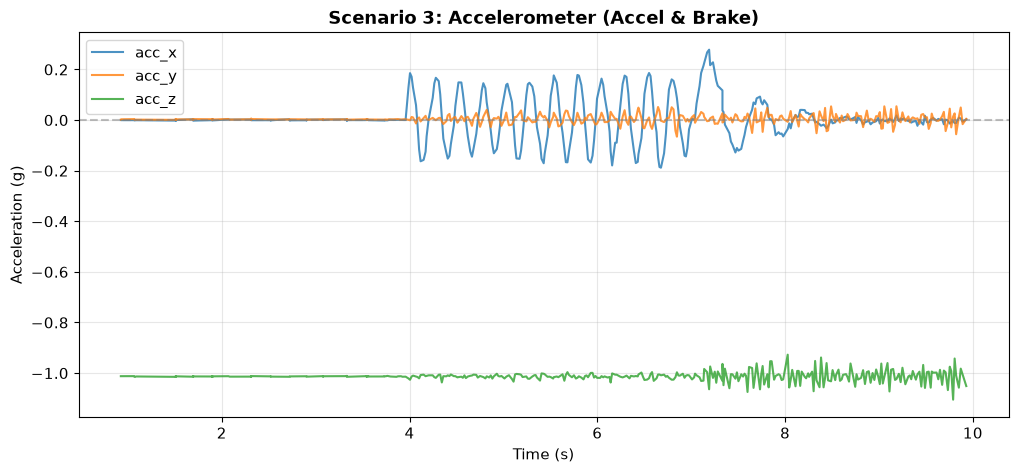

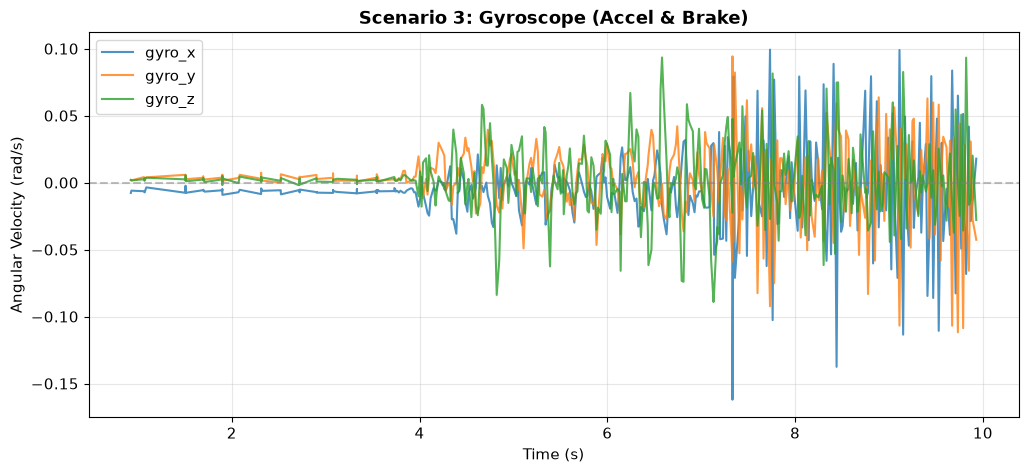

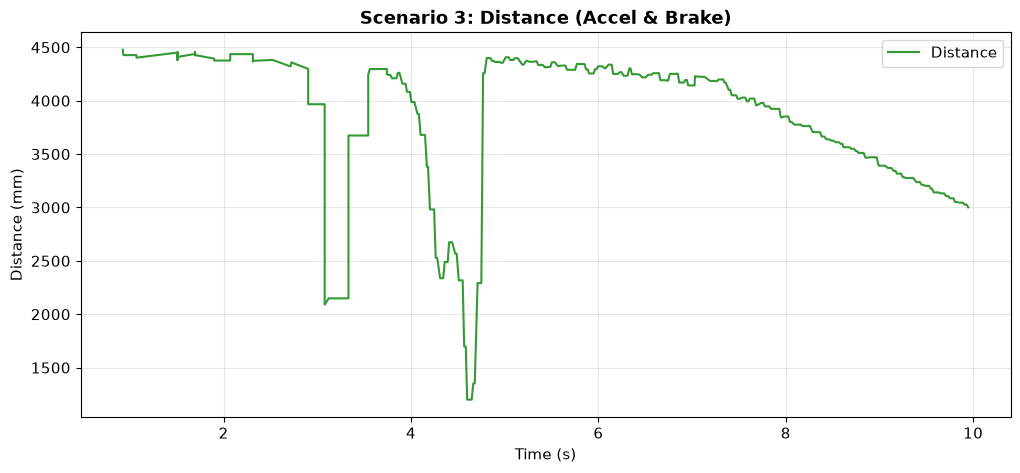

=== สถิติ Scenario 3: Accelerate & Brake ===
acc_x: mean=0.00690, std=0.08485, max_abs=0.27817
acc_y: mean=0.00432, std=0.01852, max_abs=0.06576
acc_z: mean=-1.01276, std=0.02007, max_abs=1.10496
gyro_x: mean=-0.00570, std=0.03005, max_abs=0.16205
gyro_y: mean=0.00182, std=0.02717, max_abs=0.11176
gyro_z: mean=0.00153, std=0.02627, max_abs=0.09342


In [19]:
acc3, gyro3, dist3 = data[3]

# Acceleration 
plt.figure(figsize=(12, 5))
plt.plot(acc3['Time'], acc3['acc_x'], label='acc_x', alpha=0.8)
plt.plot(acc3['Time'], acc3['acc_y'], label='acc_y', alpha=0.8)
plt.plot(acc3['Time'], acc3['acc_z'], label='acc_z', alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Scenario 3: Accelerometer (Accel & Brake)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

# Gyroscope 
plt.figure(figsize=(12, 5))
plt.plot(gyro3['Time'], gyro3['gyro_x'], label='gyro_x', alpha=0.8)
plt.plot(gyro3['Time'], gyro3['gyro_y'], label='gyro_y', alpha=0.8)
plt.plot(gyro3['Time'], gyro3['gyro_z'], label='gyro_z', alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Scenario 3: Gyroscope (Accel & Brake)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.show()

# Distance 
plt.figure(figsize=(12, 5))
plt.plot(dist3['Time'], dist3['Distance'], label='Distance', color='green', alpha=0.8)
plt.title('Scenario 3: Distance (Accel & Brake)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Distance (mm)')
plt.legend()
plt.show()

print('=== สถิติ Scenario 3: Accelerate & Brake ===')
for col in ['acc_x', 'acc_y', 'acc_z']:
    print(f'{col}: mean={np.mean(acc3[col]):.5f}, std={np.std(acc3[col]):.5f}, max_abs={np.max(np.abs(acc3[col])):.5f}')
for col in ['gyro_x', 'gyro_y', 'gyro_z']:
    print(f'{col}: mean={np.mean(gyro3[col]):.5f}, std={np.std(gyro3[col]):.5f}, max_abs={np.max(np.abs(gyro3[col])):.5f}')

---
## สถานการณ์ที่ 4: เลี้ยวซ้าย 90°

**การทดลอง:** หุ่นยนต์วิ่งตรง 3 วินาที → หมุนซ้ายประมาณ 90° → หยุด  
**วิเคราะห์:** gyro_z, acc_x, acc_y

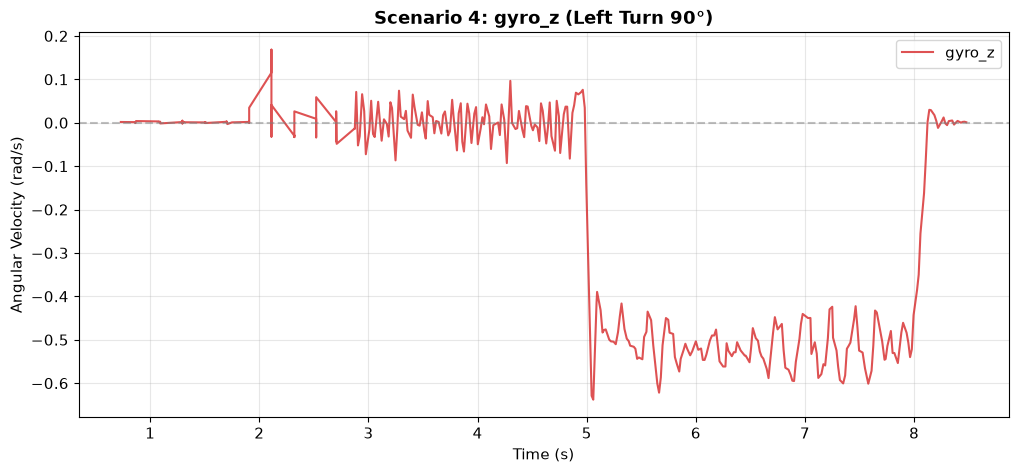

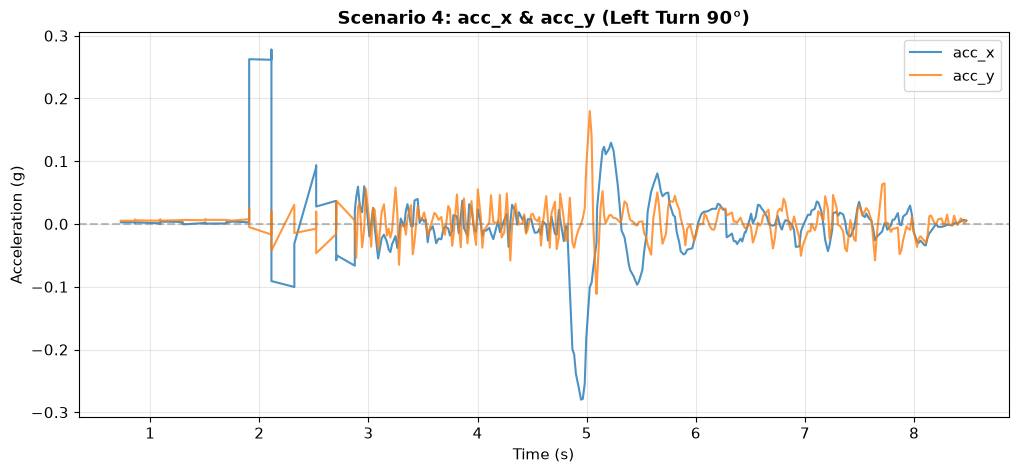

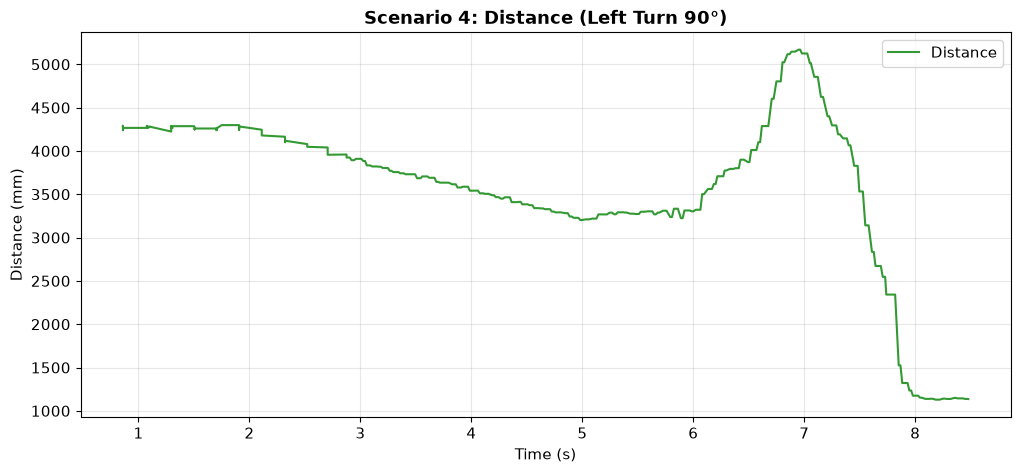

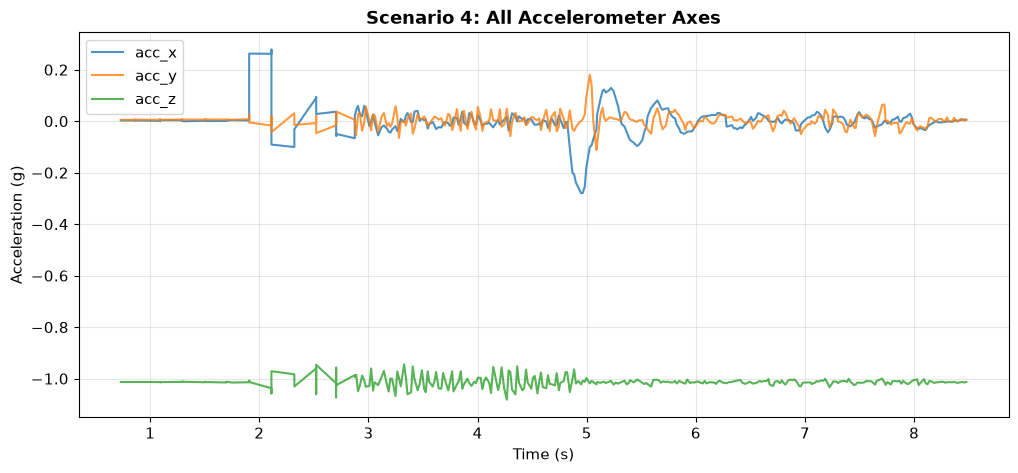

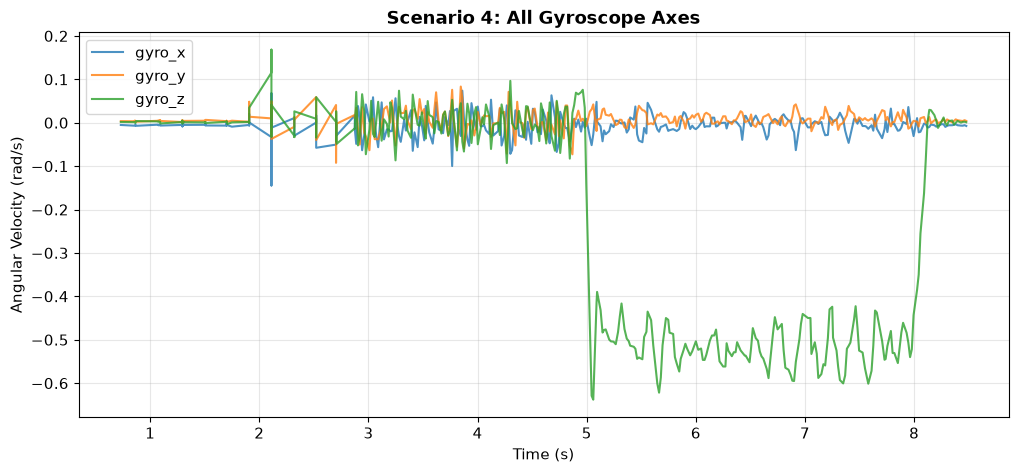

=== สถิติ Scenario 4: Left Turn 90° ===
gyro_z: mean=-0.23043, std=0.26051, max_abs=0.63807
acc_x:  mean=-0.00188, std=0.06026, max_abs=0.27991
acc_y:  mean=0.00247, std=0.02761, max_abs=0.18005


In [20]:
acc4, gyro4, dist4 = data[4]

# gyro_z 
plt.figure(figsize=(12, 5))
plt.plot(gyro4['Time'], gyro4['gyro_z'], label='gyro_z', color='tab:red', linewidth=1.5, alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Scenario 4: gyro_z (Left Turn 90°)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.show()

# acc_x & acc_y
plt.figure(figsize=(12, 5))
plt.plot(acc4['Time'], acc4['acc_x'], label='acc_x', alpha=0.8)
plt.plot(acc4['Time'], acc4['acc_y'], label='acc_y', alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Scenario 4: acc_x & acc_y (Left Turn 90°)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

# Distance 
plt.figure(figsize=(12, 5))
plt.plot(dist4['Time'], dist4['Distance'], label='Distance', color='green', alpha=0.8)
plt.title('Scenario 4: Distance (Left Turn 90°)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Distance (mm)')
plt.legend()
plt.show()

# All Accelerometer Axes 
plt.figure(figsize=(12, 5))
plt.plot(acc4['Time'], acc4['acc_x'], label='acc_x', alpha=0.8)
plt.plot(acc4['Time'], acc4['acc_y'], label='acc_y', alpha=0.8)
plt.plot(acc4['Time'], acc4['acc_z'], label='acc_z', alpha=0.8)
plt.title('Scenario 4: All Accelerometer Axes', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

# All Gyroscope Axes 
plt.figure(figsize=(12, 5))
plt.plot(gyro4['Time'], gyro4['gyro_x'], label='gyro_x', alpha=0.8)
plt.plot(gyro4['Time'], gyro4['gyro_y'], label='gyro_y', alpha=0.8)
plt.plot(gyro4['Time'], gyro4['gyro_z'], label='gyro_z', alpha=0.8)
plt.title('Scenario 4: All Gyroscope Axes', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.show()

print('=== สถิติ Scenario 4: Left Turn 90° ===')
print(f'gyro_z: mean={np.mean(gyro4["gyro_z"]):.5f}, std={np.std(gyro4["gyro_z"]):.5f}, max_abs={np.max(np.abs(gyro4["gyro_z"])):.5f}')
print(f'acc_x:  mean={np.mean(acc4["acc_x"]):.5f}, std={np.std(acc4["acc_x"]):.5f}, max_abs={np.max(np.abs(acc4["acc_x"])):.5f}')
print(f'acc_y:  mean={np.mean(acc4["acc_y"]):.5f}, std={np.std(acc4["acc_y"]):.5f}, max_abs={np.max(np.abs(acc4["acc_y"])):.5f}')

---
## สถานการณ์ที่ 5: เลี้ยวขวา 90°

**การทดลอง:** หุ่นยนต์วิ่งตรง 3 วินาที → หมุนขวาประมาณ 90° → หยุด  
**วิเคราะห์:** gyro_z, acc_x, acc_y

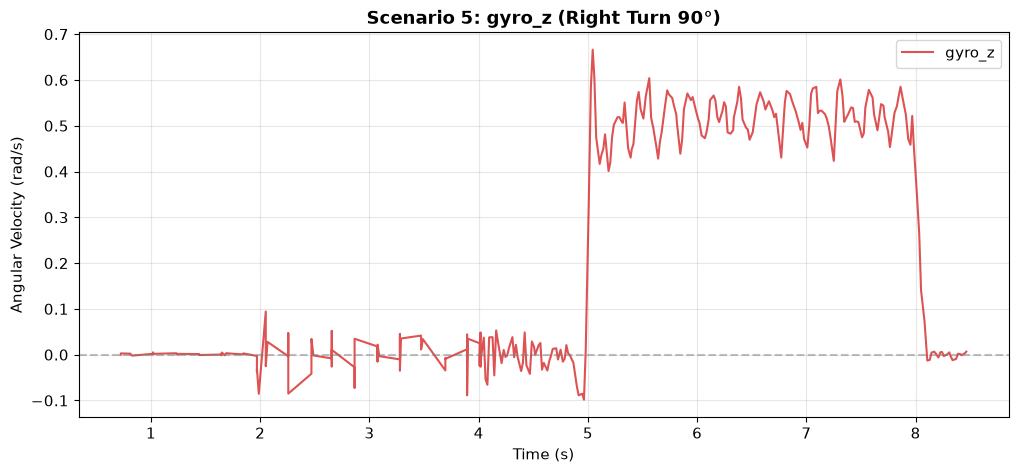

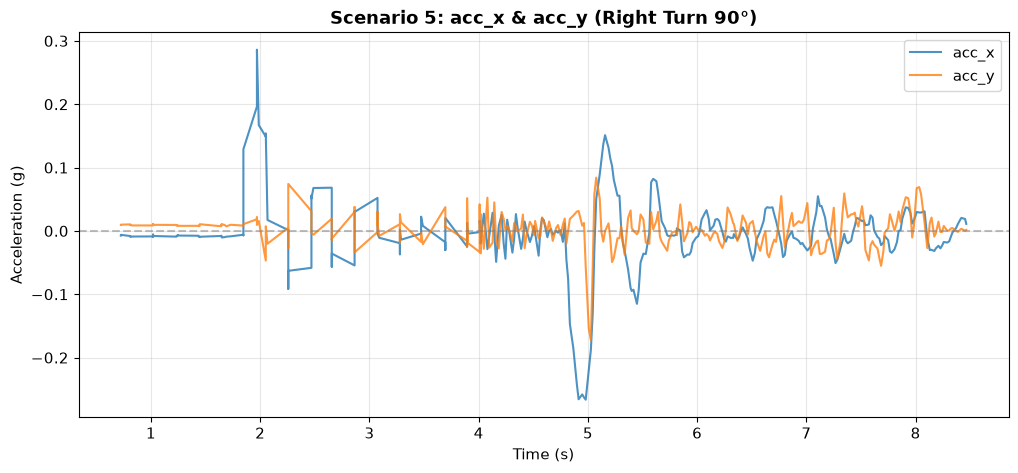

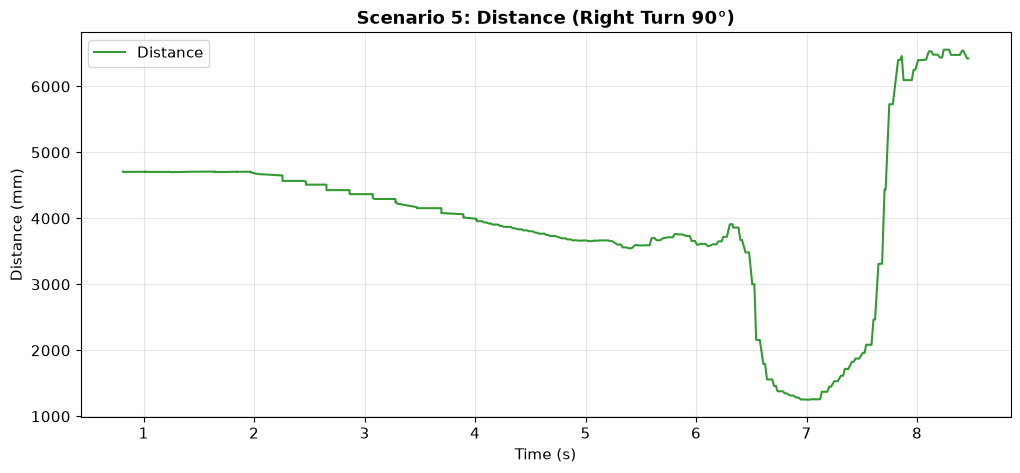

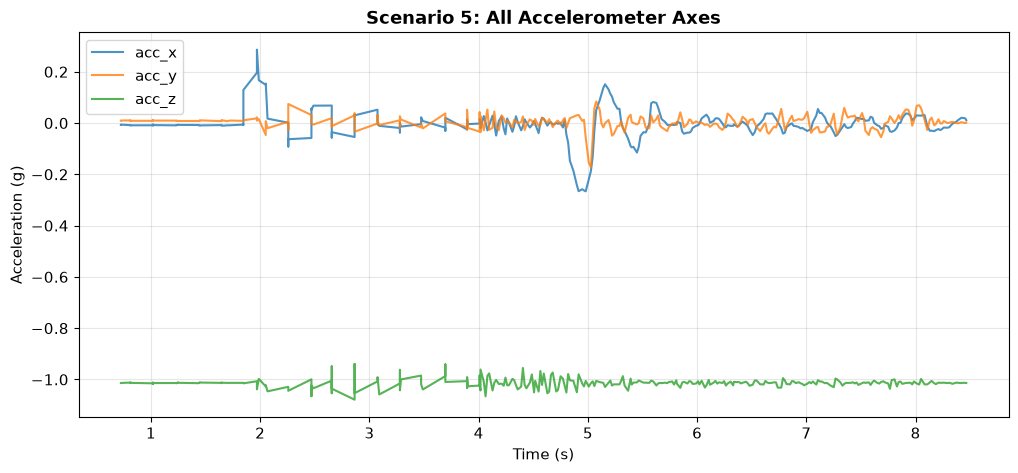

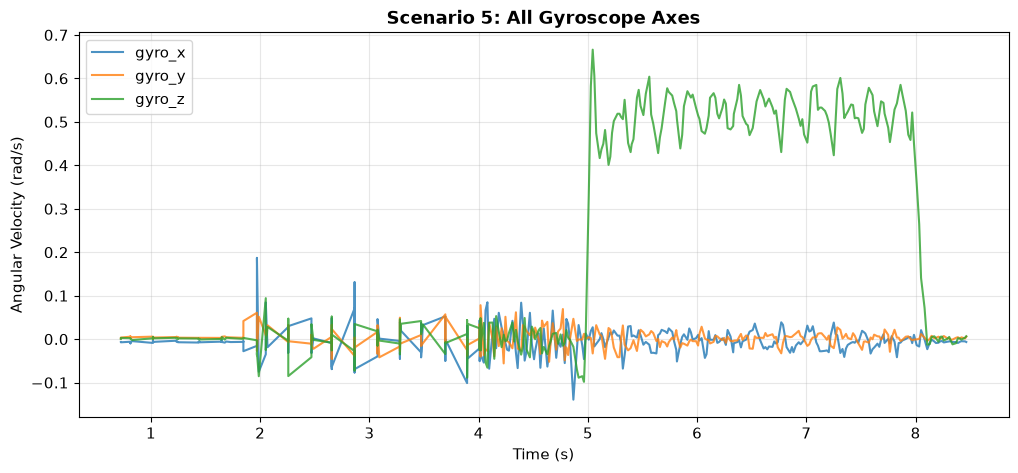

=== สถิติ Scenario 5: Right Turn 90° ===
gyro_z: mean=0.25029, std=0.26097, max_abs=0.66610
acc_x:  mean=-0.00422, std=0.05990, max_abs=0.28617
acc_y:  mean=0.00239, std=0.02656, max_abs=0.17238


In [21]:
acc5, gyro5, dist5 = data[5]

# gyro_z 
plt.figure(figsize=(12, 5))
plt.plot(gyro5['Time'], gyro5['gyro_z'], label='gyro_z', color='tab:red', linewidth=1.5, alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Scenario 5: gyro_z (Right Turn 90°)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.show()

# acc_x & acc_y 
plt.figure(figsize=(12, 5))
plt.plot(acc5['Time'], acc5['acc_x'], label='acc_x', alpha=0.8)
plt.plot(acc5['Time'], acc5['acc_y'], label='acc_y', alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Scenario 5: acc_x & acc_y (Right Turn 90°)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

# Distance
plt.figure(figsize=(12, 5))
plt.plot(dist5['Time'], dist5['Distance'], label='Distance', color='green', alpha=0.8)
plt.title('Scenario 5: Distance (Right Turn 90°)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Distance (mm)')
plt.legend()
plt.show()

# All Accelerometer Axes 
plt.figure(figsize=(12, 5))
plt.plot(acc5['Time'], acc5['acc_x'], label='acc_x', alpha=0.8)
plt.plot(acc5['Time'], acc5['acc_y'], label='acc_y', alpha=0.8)
plt.plot(acc5['Time'], acc5['acc_z'], label='acc_z', alpha=0.8)
plt.title('Scenario 5: All Accelerometer Axes', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

# All Gyroscope Axes 
plt.figure(figsize=(12, 5))
plt.plot(gyro5['Time'], gyro5['gyro_x'], label='gyro_x', alpha=0.8)
plt.plot(gyro5['Time'], gyro5['gyro_y'], label='gyro_y', alpha=0.8)
plt.plot(gyro5['Time'], gyro5['gyro_z'], label='gyro_z', alpha=0.8)
plt.title('Scenario 5: All Gyroscope Axes', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.show()

print('=== สถิติ Scenario 5: Right Turn 90° ===')
print(f'gyro_z: mean={np.mean(gyro5["gyro_z"]):.5f}, std={np.std(gyro5["gyro_z"]):.5f}, max_abs={np.max(np.abs(gyro5["gyro_z"])):.5f}')
print(f'acc_x:  mean={np.mean(acc5["acc_x"]):.5f}, std={np.std(acc5["acc_x"]):.5f}, max_abs={np.max(np.abs(acc5["acc_x"])):.5f}')
print(f'acc_y:  mean={np.mean(acc5["acc_y"]):.5f}, std={np.std(acc5["acc_y"]):.5f}, max_abs={np.max(np.abs(acc5["acc_y"])):.5f}')

---
## สถานการณ์ที่ 6: เข้าใกล้วัตถุ

**การทดลอง:** วางกล่องหรือกำแพง ให้หุ่นยนต์วิ่งเข้าหา จนระยะ 30 cm → หยุด  
**วิเคราะห์:** Distance Sensor พร้อมเปรียบเทียบกับ acc_x

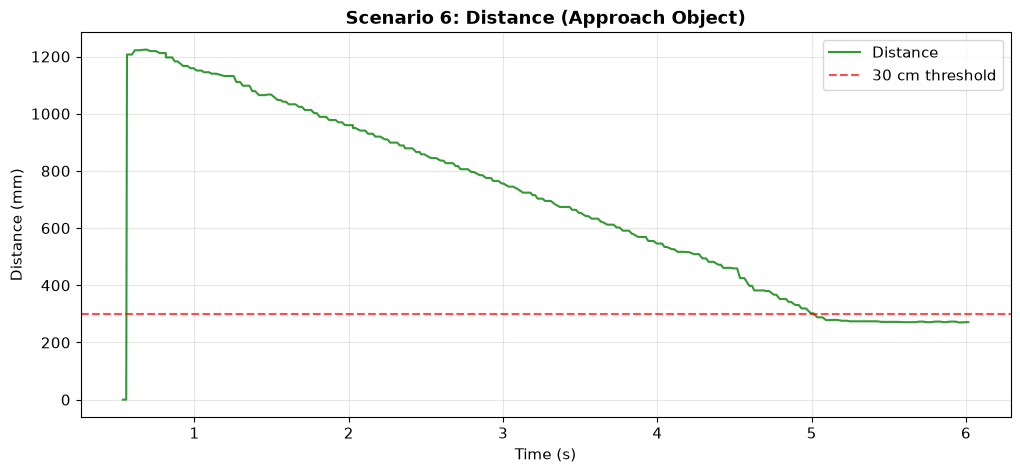

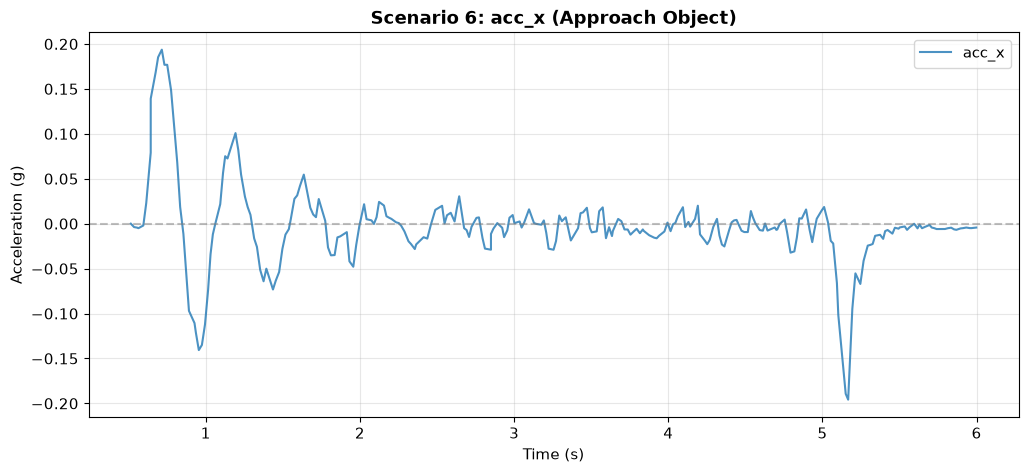

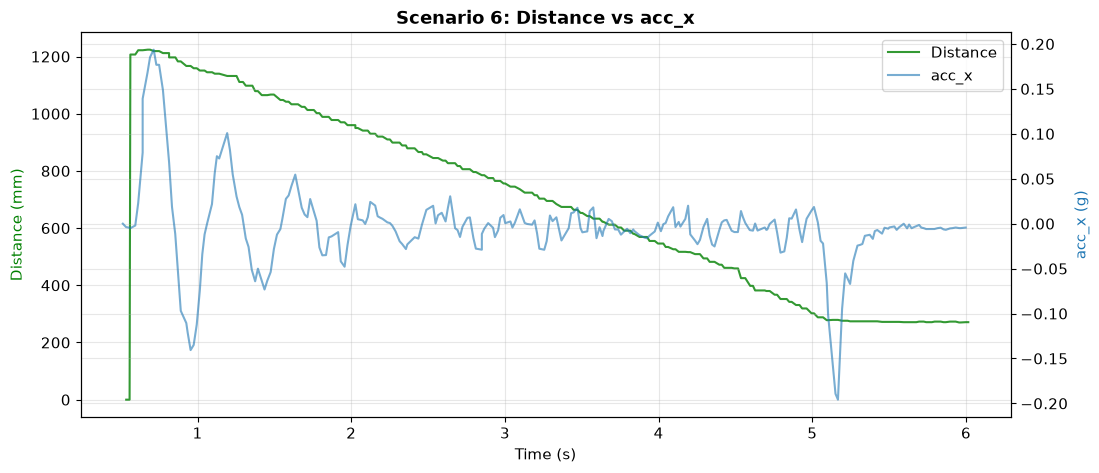

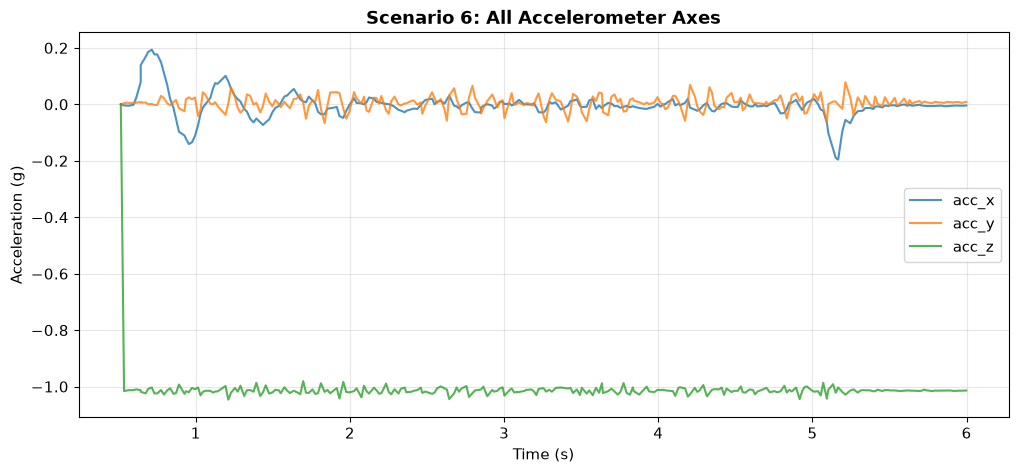

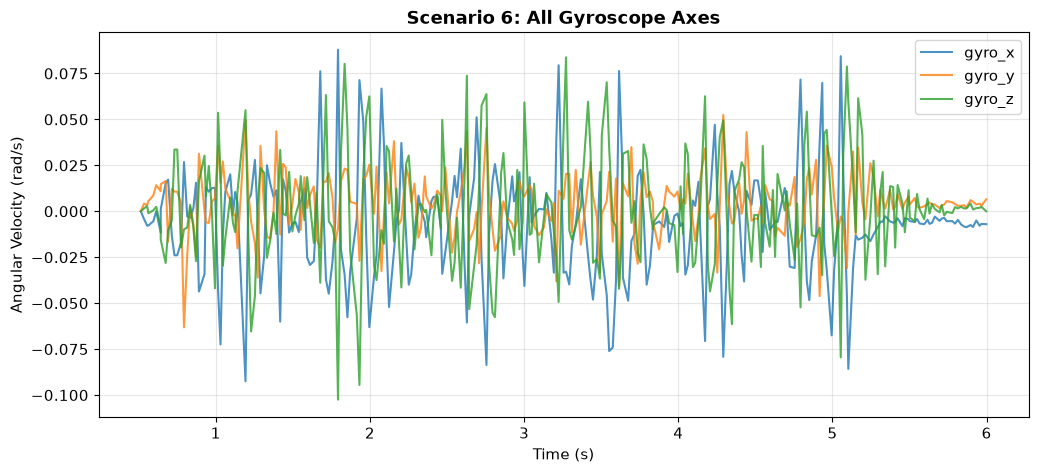

=== สถิติ Scenario 6: Approach Object ===
Distance: start=0 mm, end=271 mm, min=0 mm
acc_x: mean=-0.00400, std=0.04583, max_abs=0.19586


In [22]:
acc6, gyro6, dist6 = data[6]

# Distance Sensor
plt.figure(figsize=(12, 5))
plt.plot(dist6['Time'], dist6['Distance'], label='Distance', color='green', linewidth=1.5, alpha=0.8)
plt.axhline(y=300, color='red', linestyle='--', alpha=0.7, label='30 cm threshold')
plt.title('Scenario 6: Distance (Approach Object)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Distance (mm)')
plt.legend()
plt.show()

# acc_x
plt.figure(figsize=(12, 5))
plt.plot(acc6['Time'], acc6['acc_x'], label='acc_x', color='tab:blue', alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Scenario 6: acc_x (Approach Object)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

# Distance vs acc_x (Twin Axes)
fig, ax_dist = plt.subplots(figsize=(12, 5))
ax_acc = ax_dist.twinx()
line1, = ax_dist.plot(dist6['Time'], dist6['Distance'], label='Distance', color='green', linewidth=1.5, alpha=0.8)
line2, = ax_acc.plot(acc6['Time'], acc6['acc_x'], label='acc_x', color='tab:blue', alpha=0.6)
ax_dist.set_xlabel('Time (s)')
ax_dist.set_ylabel('Distance (mm)', color='green')
ax_acc.set_ylabel('acc_x (g)', color='tab:blue')
ax_dist.set_title('Scenario 6: Distance vs acc_x', fontsize=13, fontweight='bold')
ax_dist.legend([line1, line2], ['Distance', 'acc_x'], loc='upper right')
plt.show()

# All Accelerometer Axes
plt.figure(figsize=(12, 5))
plt.plot(acc6['Time'], acc6['acc_x'], label='acc_x', alpha=0.8)
plt.plot(acc6['Time'], acc6['acc_y'], label='acc_y', alpha=0.8)
plt.plot(acc6['Time'], acc6['acc_z'], label='acc_z', alpha=0.8)
plt.title('Scenario 6: All Accelerometer Axes', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

# All Gyroscope Axes
plt.figure(figsize=(12, 5))
plt.plot(gyro6['Time'], gyro6['gyro_x'], label='gyro_x', alpha=0.8)
plt.plot(gyro6['Time'], gyro6['gyro_y'], label='gyro_y', alpha=0.8)
plt.plot(gyro6['Time'], gyro6['gyro_z'], label='gyro_z', alpha=0.8)
plt.title('Scenario 6: All Gyroscope Axes', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.show()

print('=== สถิติ Scenario 6: Approach Object ===')
print(f'Distance: start={dist6["Distance"][0]:.0f} mm, end={dist6["Distance"][-1]:.0f} mm, min={np.min(dist6["Distance"]):.0f} mm')
print(f'acc_x: mean={np.mean(acc6["acc_x"]):.5f}, std={np.std(acc6["acc_x"]):.5f}, max_abs={np.max(np.abs(acc6["acc_x"])):.5f}')

---
## กิจกรรมที่ 4: เปรียบเทียบทุกสถานการณ์

วิเคราะห์ว่าสถานการณ์ใดทำให้:
- **Acceleration** เปลี่ยนมากที่สุด
- **Gyroscope** เปลี่ยนมากที่สุด
- **Distance** เปลี่ยนมากที่สุด

In [23]:
# คำนวณค่าการเปลี่ยนแปลงของแต่ละ scenario
scenario_names = {
    1: 'S1: Stationary',
    2: 'S2: Straight Run',
    3: 'S3: Accel & Brake',
    4: 'S4: Left Turn 90',
    5: 'S5: Right Turn 90',
    6: 'S6: Approach Object'
}

acc_ranges = []
acc_stds = []
gyro_ranges = []
gyro_stds = []
dist_ranges = []
dist_stds = []

print(f'{"Scenario":<25} {"ACC Range(g)":>12} {"ACC Std(g)":>12} {"GYRO Range":>14} {"GYRO Std":>12} {"Dist Range(mm)":>15} {"Dist Std(mm)":>13}')
print('-' * 105)

for i in range(1, 7):
    acc, gyro, dist = data[i]
    
    # Acceleration: range ของแต่ละแกน แล้วรวม magnitude
    acc_rx = np.max(acc['acc_x']) - np.min(acc['acc_x'])
    acc_ry = np.max(acc['acc_y']) - np.min(acc['acc_y'])
    acc_rz = np.max(acc['acc_z']) - np.min(acc['acc_z'])
    acc_total_range = np.sqrt(acc_rx**2 + acc_ry**2 + acc_rz**2)
    acc_std = np.sqrt(np.std(acc['acc_x'])**2 + np.std(acc['acc_y'])**2 + np.std(acc['acc_z'])**2)
    
    # Gyroscope
    gyro_rx = np.max(gyro['gyro_x']) - np.min(gyro['gyro_x'])
    gyro_ry = np.max(gyro['gyro_y']) - np.min(gyro['gyro_y'])
    gyro_rz = np.max(gyro['gyro_z']) - np.min(gyro['gyro_z'])
    gyro_total_range = np.sqrt(gyro_rx**2 + gyro_ry**2 + gyro_rz**2)
    gyro_std = np.sqrt(np.std(gyro['gyro_x'])**2 + np.std(gyro['gyro_y'])**2 + np.std(gyro['gyro_z'])**2)
    
    # Distance
    dist_range = np.max(dist['Distance']) - np.min(dist['Distance'])
    dist_std_val = np.std(dist['Distance'])
    
    acc_ranges.append(acc_total_range)
    acc_stds.append(acc_std)
    gyro_ranges.append(gyro_total_range)
    gyro_stds.append(gyro_std)
    dist_ranges.append(dist_range)
    dist_stds.append(dist_std_val)
    
    print(f'{scenario_names[i]:<25} {acc_total_range:>12.5f} {acc_std:>12.5f} {gyro_total_range:>14.5f} {gyro_std:>12.5f} {dist_range:>15.1f} {dist_std_val:>13.1f}')

Scenario                  ACC Range(g)   ACC Std(g)     GYRO Range     GYRO Std  Dist Range(mm)  Dist Std(mm)
---------------------------------------------------------------------------------------------------------
S1: Stationary                 0.01144      0.00187        0.01646      0.00269           498.0          57.2
S2: Straight Run               0.46664      0.06935        0.52379      0.04334          2973.0         783.0
S3: Accel & Brake              0.51351      0.08914        0.37952      0.04829          3278.0         656.5
S4: Left Turn 90               0.64410      0.06914        0.85372      0.26269          4040.0         929.8
S5: Right Turn 90              0.62492      0.06788        0.84187      0.26363          5305.0        1347.3
S6: Approach Object            1.12595      0.10222        0.28393      0.04413          1224.0         319.9


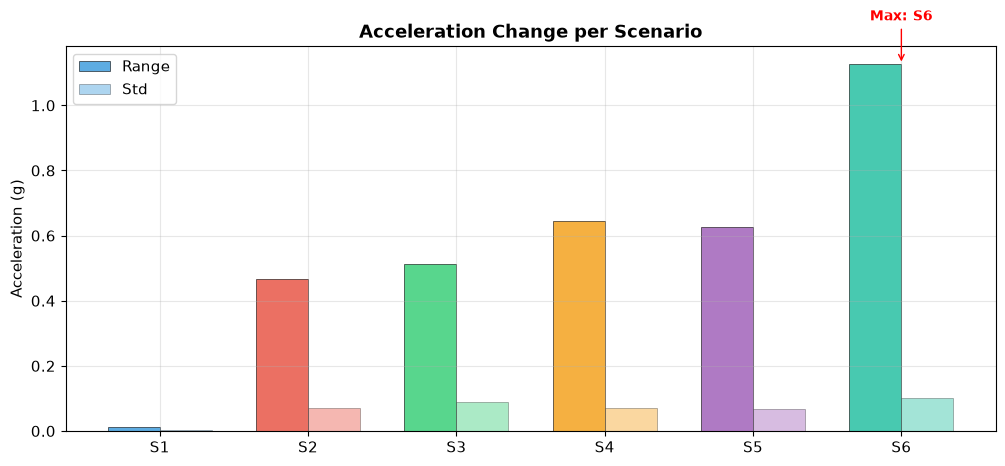

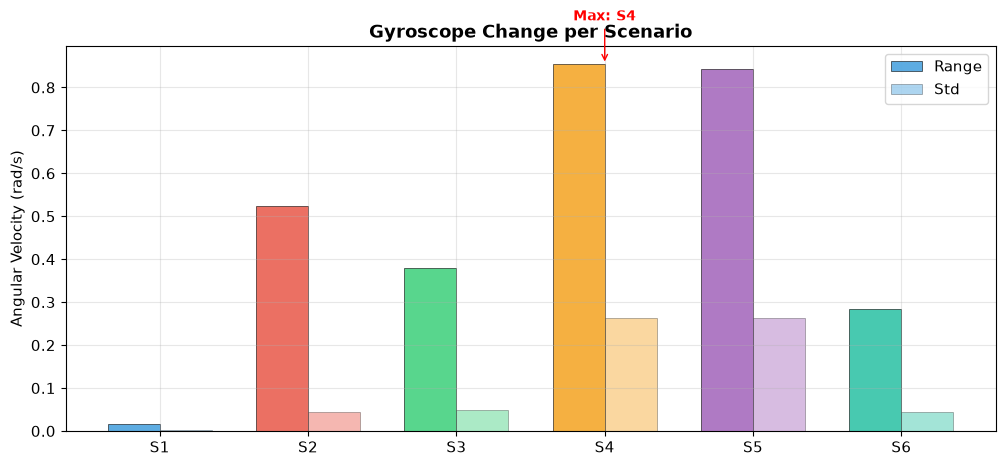

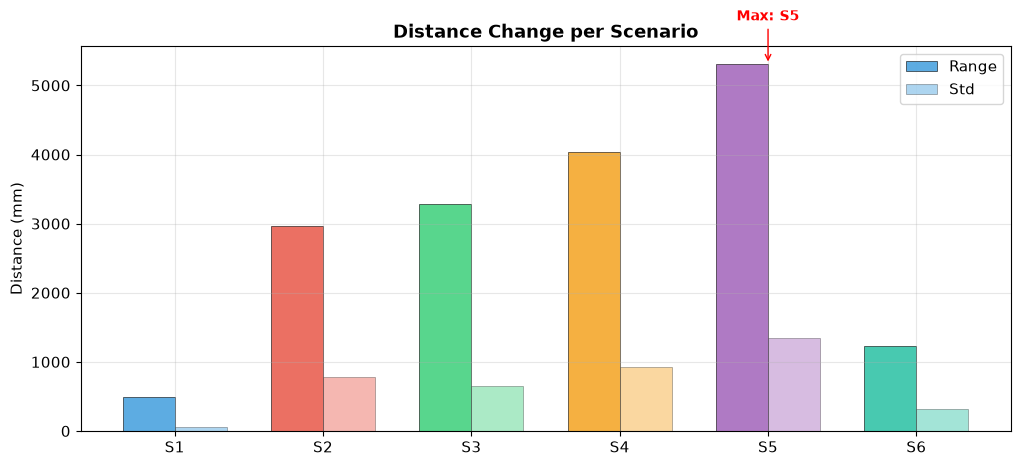

In [24]:
labels = [f'S{i}' for i in range(1, 7)]
x = np.arange(len(labels))
width = 0.35
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

# Acceleration Bar Chart
plt.figure(figsize=(12, 5))
plt.bar(x - width/2, acc_ranges, width, label='Range', color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
plt.bar(x + width/2, acc_stds, width, label='Std', color=colors, alpha=0.4, edgecolor='black', linewidth=0.5)
plt.title('Acceleration Change per Scenario', fontsize=13, fontweight='bold')
plt.ylabel('Acceleration (g)')
plt.xticks(x, labels)
plt.legend()
max_acc_idx = int(np.argmax(acc_ranges))
plt.annotate(f'Max: S{max_acc_idx+1}',
             xy=(max_acc_idx, acc_ranges[max_acc_idx]),
             xytext=(max_acc_idx, acc_ranges[max_acc_idx] * 1.12),
             ha='center', fontsize=10, fontweight='bold', color='red',
             arrowprops=dict(arrowstyle='->', color='red'))
plt.show()

# Gyroscope Bar Chart
plt.figure(figsize=(12, 5))
plt.bar(x - width/2, gyro_ranges, width, label='Range', color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
plt.bar(x + width/2, gyro_stds, width, label='Std', color=colors, alpha=0.4, edgecolor='black', linewidth=0.5)
plt.title('Gyroscope Change per Scenario', fontsize=13, fontweight='bold')
plt.ylabel('Angular Velocity (rad/s)')
plt.xticks(x, labels)
plt.legend()
max_gyro_idx = int(np.argmax(gyro_ranges))
plt.annotate(f'Max: S{max_gyro_idx+1}',
             xy=(max_gyro_idx, gyro_ranges[max_gyro_idx]),
             xytext=(max_gyro_idx, gyro_ranges[max_gyro_idx] * 1.12),
             ha='center', fontsize=10, fontweight='bold', color='red',
             arrowprops=dict(arrowstyle='->', color='red'))
plt.show()

# Distance Bar Chart
plt.figure(figsize=(12, 5))
plt.bar(x - width/2, dist_ranges, width, label='Range', color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
plt.bar(x + width/2, dist_stds, width, label='Std', color=colors, alpha=0.4, edgecolor='black', linewidth=0.5)
plt.title('Distance Change per Scenario', fontsize=13, fontweight='bold')
plt.ylabel('Distance (mm)')
plt.xticks(x, labels)
plt.legend()
max_dist_idx = int(np.argmax(dist_ranges))
plt.annotate(f'Max: S{max_dist_idx+1}',
             xy=(max_dist_idx, dist_ranges[max_dist_idx]),
             xytext=(max_dist_idx, dist_ranges[max_dist_idx] * 1.12),
             ha='center', fontsize=10, fontweight='bold', color='red',
             arrowprops=dict(arrowstyle='->', color='red'))
plt.show()

In [25]:
# สรุปผลการวิเคราะห์เปรียบเทียบ
print('         สรุปผลการเปรียบเทียบทุกสถานการณ์')

max_acc_idx = int(np.argmax(acc_ranges))
print(f'\nAcceleration เปลี่ยนมากที่สุด:')
print(f'   -> {scenario_names[max_acc_idx+1]} (Range = {acc_ranges[max_acc_idx]:.5f} g)')

max_gyro_idx = int(np.argmax(gyro_ranges))
print(f'\nGyroscope เปลี่ยนมากที่สุด:')
print(f'   -> {scenario_names[max_gyro_idx+1]} (Range = {gyro_ranges[max_gyro_idx]:.5f} rad/s)')

max_dist_idx = int(np.argmax(dist_ranges))
print(f'\nDistance เปลี่ยนมากที่สุด:')
print(f'   -> {scenario_names[max_dist_idx+1]} (Range = {dist_ranges[max_dist_idx]:.1f} mm)')


         สรุปผลการเปรียบเทียบทุกสถานการณ์

Acceleration เปลี่ยนมากที่สุด:
   -> S6: Approach Object (Range = 1.12595 g)

Gyroscope เปลี่ยนมากที่สุด:
   -> S4: Left Turn 90 (Range = 0.85372 rad/s)

Distance เปลี่ยนมากที่สุด:
   -> S5: Right Turn 90 (Range = 5305.0 mm)


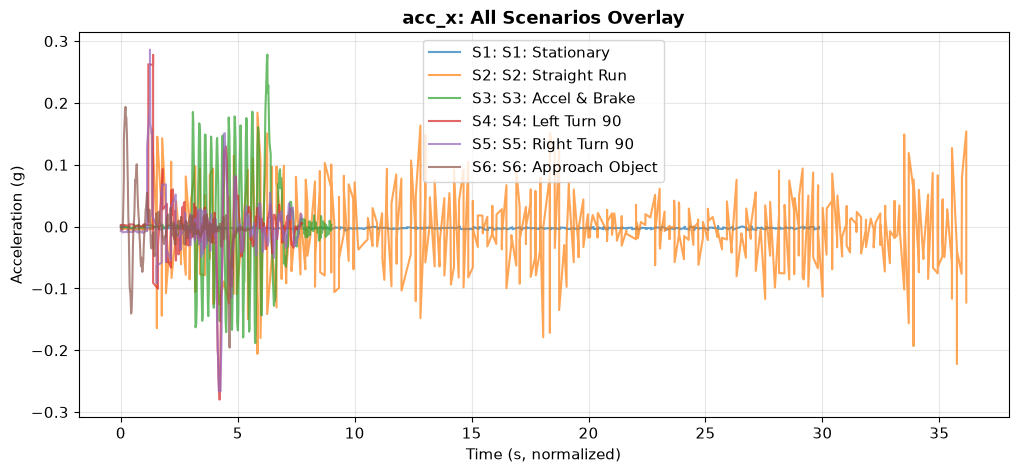

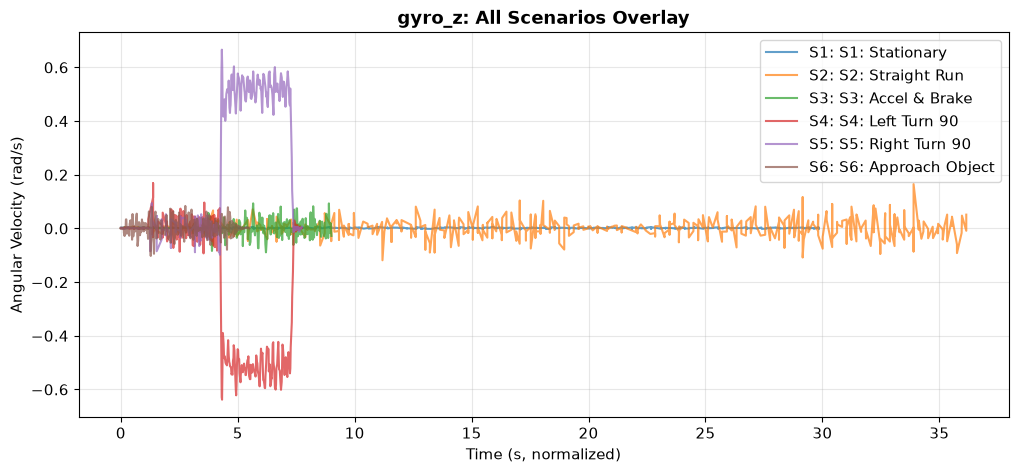

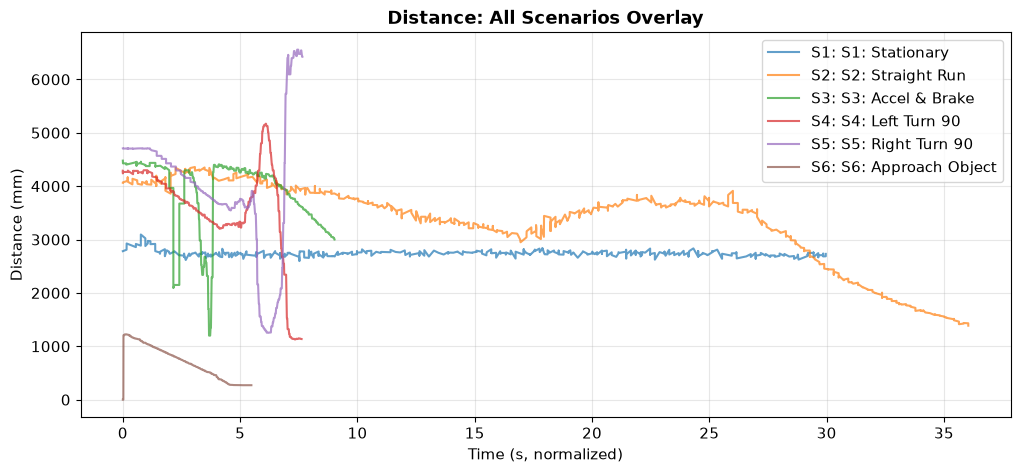

In [26]:
# เปรียบเทียบทุก Scenario ในกราฟเดียว 

# acc_x Overlay
plt.figure(figsize=(12, 5))
for i in range(1, 7):
    acc, _, _ = data[i]
    t_acc = acc['Time'] - acc['Time'][0]
    plt.plot(t_acc, acc['acc_x'], label=f'S{i}: {scenario_names[i]}', alpha=0.7)
plt.title('acc_x: All Scenarios Overlay', fontsize=13, fontweight='bold')
plt.xlabel('Time (s, normalized)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.show()

# gyro_z Overlay
plt.figure(figsize=(12, 5))
for i in range(1, 7):
    _, gyro, _ = data[i]
    t_gyro = gyro['Time'] - gyro['Time'][0]
    plt.plot(t_gyro, gyro['gyro_z'], label=f'S{i}: {scenario_names[i]}', alpha=0.7)
plt.title('gyro_z: All Scenarios Overlay', fontsize=13, fontweight='bold')
plt.xlabel('Time (s, normalized)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.show()

# Distance Overlay
plt.figure(figsize=(12, 5))
for i in range(1, 7):
    _, _, dist = data[i]
    t_dist = dist['Time'] - dist['Time'][0]
    plt.plot(t_dist, dist['Distance'], label=f'S{i}: {scenario_names[i]}', alpha=0.7)
plt.title('Distance: All Scenarios Overlay', fontsize=13, fontweight='bold')
plt.xlabel('Time (s, normalized)')
plt.ylabel('Distance (mm)')
plt.legend()
plt.show()